## Punzi figure of merit

use Punzi (2003) instead of accuracy to pick a BDT threshold that actually minimises experiment runtime.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle
import os

os.makedirs("../plots", exist_ok=True)

In [2]:
features = ["PT1", "PT2", "P1", "P2", "TotalPT", "VertexChisq", "Isolation", "MASS"]
features7 = [f for f in features if f != "MASS"]

signal = pd.read_csv("../data/signal_Bs2MuMu.txt", sep=r"\s+", header=None, names=features)
background = pd.read_csv("../data/background_combinatorial.txt", sep=r"\s+", header=None, names=features)
signal = signal.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
background = background.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

with open("../bdt_model.pkl", "rb") as fh:
    bdt7 = pickle.load(fh)
with open("../bdt_results.json") as fh:
    bdt_results = json.load(fh)

In [3]:
scores_sig = bdt7.predict_proba(signal[features7])[:, 1]
scores_bkg = bdt7.predict_proba(background[features7])[:, 1]

N_BKG_YEAR = 2000
n_sigma = 5.0
bkg_eff_floor = 1.0 / len(background)   # 10k MC events -> can't measure below this

thresholds = np.linspace(0.01, 0.99, 300)
fom_vals, acc_vals, sig_eff_scan, bkg_eff_scan = [], [], [], []
for t in thresholds:
    eps_s = (scores_sig >= t).mean()
    eps_b = max((scores_bkg >= t).mean(), bkg_eff_floor)
    B = N_BKG_YEAR * eps_b
    fom_vals.append(eps_s / (n_sigma / 2 + np.sqrt(B)))
    acc_vals.append(((scores_sig >= t).sum() + (scores_bkg < t).sum()) / (len(scores_sig) + len(scores_bkg)))
    sig_eff_scan.append(eps_s)
    bkg_eff_scan.append(eps_b)

fom_vals, acc_vals = np.array(fom_vals), np.array(acc_vals)
sig_eff_scan, bkg_eff_scan = np.array(sig_eff_scan), np.array(bkg_eff_scan)

i_fom, i_acc = int(np.argmax(fom_vals)), int(np.argmax(acc_vals))
sig_eff_punzi, bkg_eff_punzi = sig_eff_scan[i_fom], bkg_eff_scan[i_fom]

print(f"Punzi:    t = {thresholds[i_fom]:.3f}, sig_eff = {sig_eff_punzi:.4f}, bkg_eff = {bkg_eff_punzi:.4f}")
print(f"Accuracy: t = {thresholds[i_acc]:.3f}, sig_eff = {sig_eff_scan[i_acc]:.4f}, bkg_eff = {bkg_eff_scan[i_acc]:.4f}")

Punzi:    t = 0.626, sig_eff = 0.5903, bkg_eff = 0.0072
Accuracy: t = 0.479, sig_eff = 0.9619, bkg_eff = 0.0964


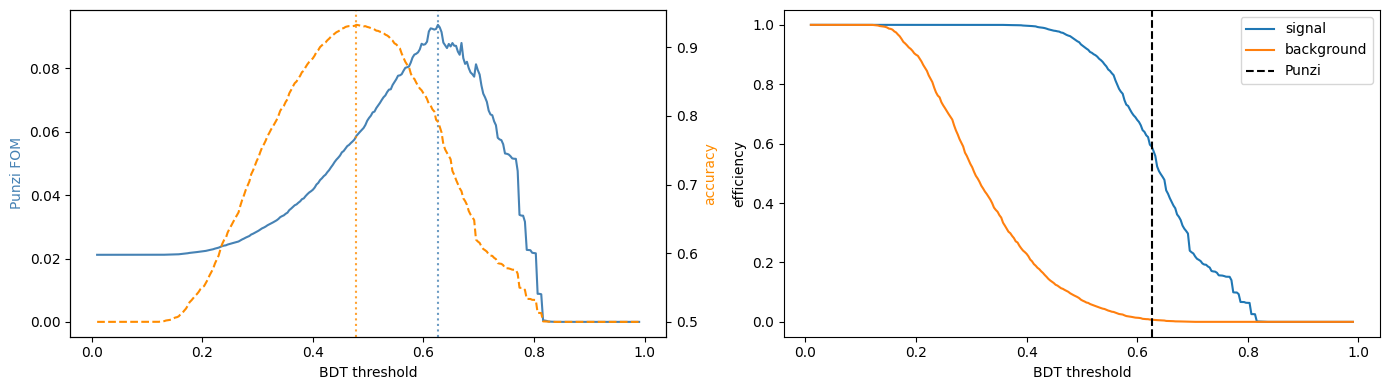

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax2 = ax.twinx()
ax.plot(thresholds, fom_vals, color="steelblue", label="Punzi FOM")
ax2.plot(thresholds, acc_vals, color="darkorange", linestyle="--", label="accuracy")
ax.axvline(thresholds[i_fom], color="steelblue", linestyle=":", alpha=0.8)
ax.axvline(thresholds[i_acc], color="darkorange", linestyle=":", alpha=0.8)
ax.set_xlabel("BDT threshold"); ax.set_ylabel("Punzi FOM", color="steelblue")
ax2.set_ylabel("accuracy", color="darkorange")

ax = axes[1]
ax.plot(thresholds, sig_eff_scan, label="signal")
ax.plot(thresholds, bkg_eff_scan, label="background")
ax.axvline(thresholds[i_fom], linestyle="--", color="black", label="Punzi")
ax.set_xlabel("BDT threshold"); ax.set_ylabel("efficiency"); ax.legend()

plt.tight_layout()
plt.savefig("../plots/punzi_fom.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# S/sqrt(B) drives discovery time (T ~ 1 / (S/sqrt(B))^2)
sens_punzi = (50 * sig_eff_punzi) / np.sqrt(N_BKG_YEAR * bkg_eff_punzi)
sens_acc = (50 * sig_eff_scan[i_acc]) / np.sqrt(N_BKG_YEAR * bkg_eff_scan[i_acc])
print(f"S/sqrt(B): Punzi = {sens_punzi:.3f}, accuracy = {sens_acc:.3f}, gain = {sens_punzi/sens_acc:.3f}x")

punzi_results = {
    "punzi_threshold": float(thresholds[i_fom]),
    "signal_efficiency_punzi": float(sig_eff_punzi),
    "background_efficiency_punzi": float(bkg_eff_punzi),
}
with open("../punzi_results.json", "w") as fh:
    json.dump(punzi_results, fh, indent=2)

S/sqrt(B): Punzi = 7.778, accuracy = 3.464, gain = 2.246x


### Discovery time at the Punzi working point

self-contained toy MC at the Punzi WP (same procedure as `mass_fit.ipynb`): fit `lambda` on the background sample, generate 1-year toys, compute the composite-PDF signal fraction, and scan experiment durations for the 95% 5σ crossing.

In [6]:
from scipy.optimize import minimize
from scipy.stats import norm

bkg_mass = background["MASS"].to_numpy()
MASS_LO, MASS_HI = 4.0, 6.0
MU_SIG, SIG_SIG = 5.0, 0.03

def exp_pdf(m, lam):
    return np.exp(-lam*m) / ((np.exp(-lam*MASS_LO) - np.exp(-lam*MASS_HI))/lam)

def nll_bkg(params, masses):
    lam = params[0]
    if lam <= 0: return 1e10
    return -np.sum(np.log(exp_pdf(masses, lam)))

lam_fit = float(minimize(nll_bkg, x0=[0.5], args=(bkg_mass,), method="Nelder-Mead").x[0])

def sample_exp(lam, n, rng):
    u = rng.uniform(0, 1, size=n)
    return -np.log(np.exp(-lam*MASS_LO) - u*(np.exp(-lam*MASS_LO) - np.exp(-lam*MASS_HI))) / lam

def gen_toy(ns_mean, nb_mean, lam, rng):
    m = np.concatenate([
        rng.normal(MU_SIG, SIG_SIG, rng.poisson(ns_mean)),
        sample_exp(lam, rng.poisson(nb_mean), rng),
    ])
    return m[(m >= MASS_LO) & (m <= MASS_HI)]

def composite_pdf(m, fs, lam):
    return fs * norm.pdf(m, MU_SIG, SIG_SIG) + (1-fs) * exp_pdf(m, lam)

def nll_comp(params, masses):
    fs, lam = params
    if fs < 0 or fs > 1 or lam <= 0: return 1e10
    v = composite_pdf(masses, fs, lam)
    if np.any(v <= 0): return 1e10
    return -np.sum(np.log(v))

def fit_toy(masses):
    r = minimize(nll_comp, x0=[0.02, lam_fit], args=(masses,), method="Nelder-Mead",
                 options={"xatol":1e-5, "fatol":1e-5, "maxiter":5000})
    return float(r.fun)

def fit_bkg(masses):
    r = minimize(nll_bkg, x0=[lam_fit], args=(masses,), method="Nelder-Mead")
    return float(r.fun)

def run_significances(T, n_toys, rng):
    ns, nb = 50*sig_eff_punzi*T, N_BKG_YEAR*bkg_eff_punzi*T
    sigs = []
    for _ in range(n_toys):
        toy = gen_toy(ns, nb, lam_fit, rng)
        nll1 = fit_toy(toy); nll0 = fit_bkg(toy)
        sigs.append(np.sqrt(max(0.0, 2*(nll0 - nll1))))
    return np.array(sigs)

rng = np.random.default_rng(42)
z_1yr = run_significances(1.0, 1000, rng)
med_Z = float(np.median(z_1yr))
print(f"Punzi 1-yr median Z = {med_Z:.2f}, frac > 5 sigma = {(z_1yr>5).mean():.3f}")

durations = np.round(np.arange(0.1, 1.55, 0.1), 1)
probs = np.array([(run_significances(T, 300, rng) > 5).mean() for T in durations])
for T, p in zip(durations, probs):
    print(f"T = {T:.1f} yr  P(>5 sigma) = {p:.3f}")
idx = np.where(probs >= 0.95)[0]
T95 = float(durations[idx[0]]) if len(idx) else None
print(f"T95 (Punzi) = {T95} yr")

Punzi 1-yr median Z = 10.84, frac > 5 sigma = 1.000


/sessions/nice-friendly-bohr/tmp/ipykernel_216/2197617111.py:9: RuntimeWarning: invalid value encountered in divide
  return np.exp(-lam*m) / ((np.exp(-lam*MASS_LO) - np.exp(-lam*MASS_HI))/lam)
/sessions/nice-friendly-bohr/tmp/ipykernel_216/2197617111.py:9: RuntimeWarning: divide by zero encountered in divide
  return np.exp(-lam*m) / ((np.exp(-lam*MASS_LO) - np.exp(-lam*MASS_HI))/lam)


T = 0.1 yr  P(>5 sigma) = 0.127
T = 0.2 yr  P(>5 sigma) = 0.493
T = 0.3 yr  P(>5 sigma) = 0.760
T = 0.4 yr  P(>5 sigma) = 0.920
T = 0.5 yr  P(>5 sigma) = 0.973
T = 0.6 yr  P(>5 sigma) = 0.997
T = 0.7 yr  P(>5 sigma) = 1.000
T = 0.8 yr  P(>5 sigma) = 1.000
T = 0.9 yr  P(>5 sigma) = 1.000
T = 1.0 yr  P(>5 sigma) = 1.000
T = 1.1 yr  P(>5 sigma) = 1.000
T = 1.2 yr  P(>5 sigma) = 1.000
T = 1.3 yr  P(>5 sigma) = 1.000
T = 1.4 yr  P(>5 sigma) = 1.000
T = 1.5 yr  P(>5 sigma) = 1.000
T95 (Punzi) = 0.5 yr


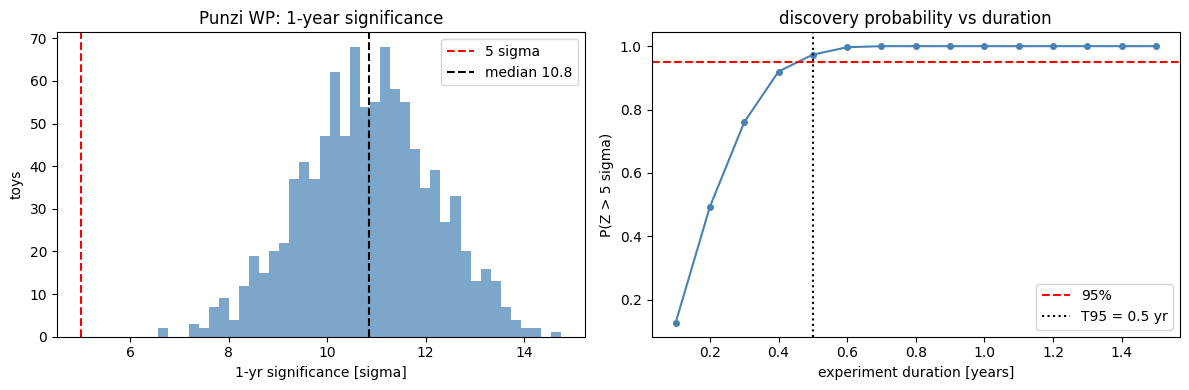

saved punzi_results.json with discovery-time numbers


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(z_1yr, bins=40, alpha=0.7, color="steelblue")
ax.axvline(5, color="red", linestyle="--", label="5 sigma")
ax.axvline(med_Z, color="black", linestyle="--", label=f"median {med_Z:.1f}")
ax.set_xlabel("1-yr significance [sigma]"); ax.set_ylabel("toys"); ax.legend()
ax.set_title("Punzi WP: 1-year significance")

ax = axes[1]
ax.plot(durations, probs, marker="o", markersize=4, color="steelblue")
ax.axhline(0.95, color="red", linestyle="--", label="95%")
if T95 is not None:
    ax.axvline(T95, color="black", linestyle=":", label=f"T95 = {T95} yr")
ax.set_xlabel("experiment duration [years]"); ax.set_ylabel("P(Z > 5 sigma)")
ax.legend(); ax.set_title("discovery probability vs duration")
plt.tight_layout()
plt.savefig("../plots/discovery_duration_punzi.png", dpi=150, bbox_inches="tight")
plt.show()

punzi_results["median_significance_1yr_punzi"] = med_Z
punzi_results["T95_punzi_years"] = T95
with open("../punzi_results.json", "w") as fh:
    json.dump(punzi_results, fh, indent=2)
print("saved punzi_results.json with discovery-time numbers")